# Student Cost of Living in Prague
## Data Processing in Python 
Anna Chodurková, Barbora Motyková

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display, Math

In [3]:
from source_code.loaders import (
    # Constants
    TRANSPORT_MONTHLY,
    LEISURE_MONTHLY,
    
    # Housing
    load_apartments,
    load_apartment_district_stats,
    load_apartments_clean,
    load_dorms,
    
    # Food
    load_canteen,
    load_groceries_basket,
    load_groceries_full
)

In [4]:
from source_code.cost_model import (
    build_scenario_table,
    get_cost_insights,
    compute_monthly_cost
)

# Housing analysis 


In [5]:
apartments = load_apartments_clean()
district_stats = load_apartment_district_stats()
dorms = load_dorms()

In [6]:
apartments

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2,zone
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Kyje,19200,1+KK,581.818182,outer_or_suburbs
1,40621,7168,40,NaN,"Starokošířská, Praha - Košíře",Košíře,47789,unknown,1194.725000,inner_city
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Stodůlky,34000,3+KK,425.000000,outer_or_suburbs
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Vysočany,15990,1+KK,484.545455,inner_city
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Košíře,27500,2+1,539.215686,inner_city
...,...,...,...,...,...,...,...,...,...,...
1226,34900,12049,71,DISP_3_1,"Francouzská, Praha - Vinohrady",Vinohrady,46949,3+1,661.253521,inner_city
1227,31987,5645,31,NaN,"Kmochova, Praha - Smíchov",Smíchov,37632,unknown,1213.935484,inner_city
1228,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Holešovice,27000,2+KK,642.857143,inner_city
1229,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Podolí,22500,2+KK,523.255814,inner_city


In [7]:
district_stats

,zone,disposition_clean,avg_rent,avg_m2_price,count
0,center,1+1,22566.666667,687.672533,3
1,center,1+KK,25472.857143,976.291126,7
2,center,2+1,32422.222222,493.355657,9
3,center,2+KK,32351.250000,718.018330,8
4,center,3+1,35800.000000,421.176471,1
5,center,3+KK,36000.000000,500.000000,3
6,center,unknown,45610.200000,1390.823892,15
7,inner_city,1+1,21398.333333,545.719975,36
8,inner_city,1+KK,21562.980892,706.096441,157
9,inner_city,2+1,27749.073171,469.820999,82


### 1. How affordable are apartments in Prague?

In [8]:
#create price categories
bins = [0,15000,25000,35000,60000]
labels=["very_cheap", "lower_student", "upper_student", "luxury"]

apartments["price_group"] = pd.cut(
    apartments["full_cost"],
    bins=bins,
    labels=labels)

In [9]:
vc=apartments["price_group"].value_counts(normalize=True)*100
vc

price_group
upper_student    39.967506
lower_student    38.830219
luxury           17.140536
very_cheap        4.061738
Name: proportion, dtype: float64

In [10]:
for label, left, right in zip(labels, bins[:-1], bins[1:]):
    print(f"{label} apartments ({left}–{right}) make {vc[label]:.2f}% of the market")

very_cheap apartments (0–15000) make 4.06% of the market
lower_student apartments (15000–25000) make 38.83% of the market
upper_student apartments (25000–35000) make 39.97% of the market
luxury apartments (35000–60000) make 17.14% of the market


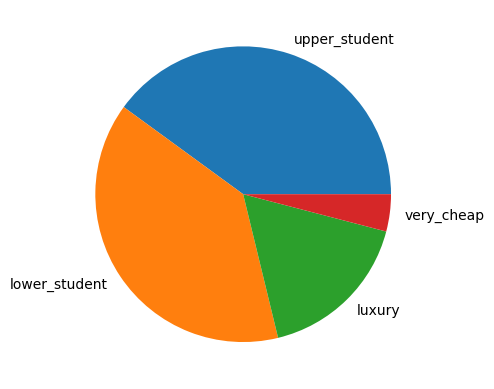

In [11]:
counts=apartments["price_group"].value_counts()
plt.pie(counts,labels=counts.index)
plt.show()

1.
Only 4% of Prague apartments fall below 15 000 CZK/month, making cheap 
housing extremely rare. The majority of listings fall into the lower_student 
(15 000–25 000) and upper_student (25 000–35 000) categories.    
Luxury apartments (above 35 000) make up a significant share of the market, 
reflecting Prague's overall high rental prices.

### 2. Does location affect apartment prices?

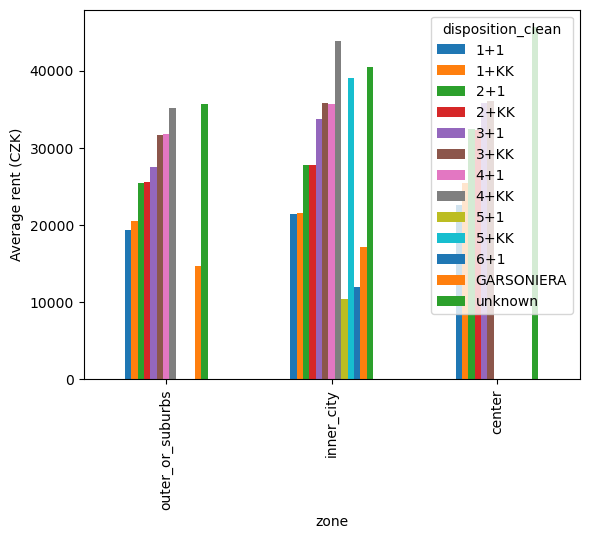

In [12]:
pivot = district_stats.pivot(index="zone", columns="disposition_clean", values="avg_rent")

# sort rows by overall average rent across zones
pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

pivot.plot.bar()

plt.ylabel("Average rent (CZK)")
plt.show()

In [13]:
#Luxury and upper_student apartments are concentrated in the center 
#Outer districs contain a larger proportion of affordable housing   
pd.crosstab(apartments["zone"],apartments["price_group"],normalize="index")

price_group,very_cheap,lower_student,upper_student,luxury
zone,,,,
center,0.000000,0.108696,0.478261,0.413043
inner_city,0.034621,0.347537,0.415446,0.202397
outer_or_suburbs,0.055300,0.488479,0.364055,0.092166


2. 
Location has a clear effect on absolute rent — central apartments are 
consistently more expensive across all apartment types.   
However, the effect is not uniform: larger apartments show smaller price differences between zones, while smaller apartments (1+KK) carry a strong central premium.   
Outer districts and suburbs contain a disproportionately large share of affordable housing, making them the realistic option for budget-conscious students.

### 3. Which apartment type provides the best value?

In [14]:
district_stats.sort_values("avg_m2_price")[["zone", "disposition_clean", "avg_m2_price"]]


,zone,disposition_clean,avg_m2_price
17,inner_city,6+1,92.307692
15,inner_city,5+1,122.364706
26,outer_or_suburbs,4+1,302.726352
27,outer_or_suburbs,4+KK,334.415775
24,outer_or_suburbs,3+1,349.010886
13,inner_city,4+1,383.336364
11,inner_city,3+1,403.396254
4,center,3+1,421.176471
25,outer_or_suburbs,3+KK,425.715397
14,inner_city,4+KK,432.319556


In [15]:
zone_means = district_stats.groupby("zone")["avg_m2_price"].mean()
zone_effect = zone_means.var()
size_means = district_stats.groupby("disposition_clean")["avg_m2_price"].mean()
size_effect = size_means.var()
print(f"Zone effect: {zone_effect} \nSize effect: {size_effect}")


Zone effect: 19640.596116703622 
Size effect: 72549.85880830267


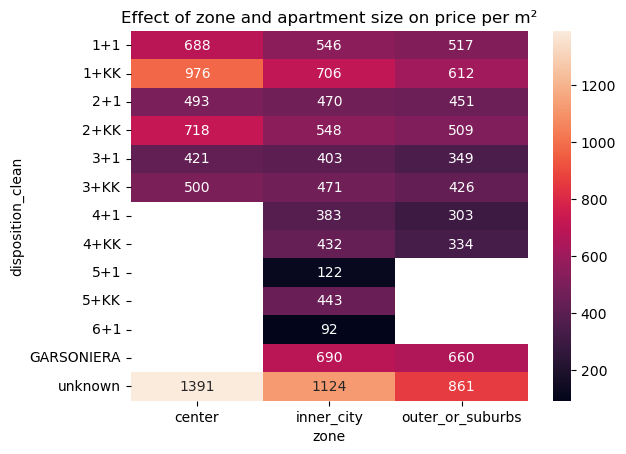

In [17]:
pivot = district_stats.pivot(
    index="disposition_clean",
    columns="zone",
    values="avg_m2_price"
)

sns.heatmap(pivot,annot=True,fmt=".0f")
plt.title("Effect of zone and apartment size on price per m²")
plt.show()
#Apartments in the center have higher prices, while suburban areas are cheaper  

#Smaller apartments are signigicantly more expensive per m2 than larger apartments, regrdless of location

#interaction effect:   
    #Small apartments benefit more from central location   
    #Large apartments lose value efficiency even in good location

3. 
Apartment size matters more than location for price per m².   
Larger apartments (3+KK) offer significantly better value per m² regardless of zone, while smaller apartments (1+KK) are inefficient per m² even in cheaper areas.     
There is an interaction effect: small apartments in the center carry a double 
penalty — high absolute price and poor m² efficiency.    
Large apartments lose 
value efficiency in central locations too, but the effect is smaller.

### 4. Is sharing accommodation worthwhile?

In [18]:
apartments

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2,zone,price_group
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Kyje,19200,1+KK,581.818182,outer_or_suburbs,lower_student
1,40621,7168,40,NaN,"Starokošířská, Praha - Košíře",Košíře,47789,unknown,1194.725000,inner_city,luxury
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Stodůlky,34000,3+KK,425.000000,outer_or_suburbs,upper_student
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Vysočany,15990,1+KK,484.545455,inner_city,lower_student
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Košíře,27500,2+1,539.215686,inner_city,upper_student
...,...,...,...,...,...,...,...,...,...,...,...
1226,34900,12049,71,DISP_3_1,"Francouzská, Praha - Vinohrady",Vinohrady,46949,3+1,661.253521,inner_city,luxury
1227,31987,5645,31,NaN,"Kmochova, Praha - Smíchov",Smíchov,37632,unknown,1213.935484,inner_city,luxury
1228,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Holešovice,27000,2+KK,642.857143,inner_city,upper_student
1229,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Podolí,22500,2+KK,523.255814,inner_city,lower_student


In [19]:
sharing=apartments[apartments["disposition_clean"]!="unknown"].copy()

sharing["people"]=(
    sharing["disposition_clean"]
    .replace("GARSONIERA","1+KK")
    .str.split("+").str[0].astype(int)
)

In [20]:
sharing

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2,zone,price_group,people
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Kyje,19200,1+KK,581.818182,outer_or_suburbs,lower_student,1
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Stodůlky,34000,3+KK,425.000000,outer_or_suburbs,upper_student,3
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Vysočany,15990,1+KK,484.545455,inner_city,lower_student,1
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Košíře,27500,2+1,539.215686,inner_city,upper_student,2
6,14990,0,45,DISP_2_KK,"Donská, Praha - Vršovice",Vršovice,14990,2+KK,333.111111,inner_city,very_cheap,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1225,21000,3000,41,DISP_2_KK,"Vorařská, Praha - Modřany",Modřany,24000,2+KK,585.365854,outer_or_suburbs,lower_student,2
1226,34900,12049,71,DISP_3_1,"Francouzská, Praha - Vinohrady",Vinohrady,46949,3+1,661.253521,inner_city,luxury,3
1228,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Holešovice,27000,2+KK,642.857143,inner_city,upper_student,2
1229,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Podolí,22500,2+KK,523.255814,inner_city,lower_student,2


In [21]:
sharing["price_per_person"]=sharing["full_cost"]/sharing["people"]

In [22]:
groups=sharing.groupby("people")["price_per_person"].mean()
groups

people
1    20848.036723
2    13584.274225
3    10912.089820
4     9597.342593
5     4940.100000
6     2000.000000
Name: price_per_person, dtype: float64

In [23]:
baseline=groups.loc[1]

savings=baseline-groups
savings_pct=(savings/baseline)*100

In [24]:
sharing_stats=pd.DataFrame({
    "avg_cost_per_person":groups,
    "savings_czk": savings,
    "savings_pct": savings_pct
})
sharing_stats

,avg_cost_per_person,savings_czk,savings_pct
people,,,
1,20848.036723,0.000000,0.000000
2,13584.274225,7263.762498,34.841470
3,10912.089820,9935.946903,47.658909
4,9597.342593,11250.694131,53.965245
5,4940.100000,15907.936723,76.304244
6,2000.000000,18848.036723,90.406771


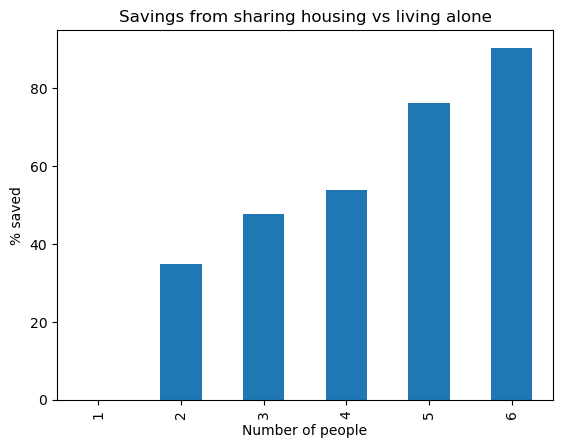

In [25]:
sharing_stats["savings_pct"].plot(kind="bar")
plt.title("Savings from sharing housing vs living alone")
plt.ylabel("% saved")
plt.xlabel("Number of people")
plt.show()

$$
\text{Total savings} =
\frac{cost_{\text{alone}} - cost_{\text{group}}}{cost_{\text{alone}}} \times 100
$$

$$
\text{Marginal change} =
\frac{cost_{\text{previous}} - cost_{\text{current}}}{cost_{\text{previous}}} \times 100
$$

In [26]:
for people, row in sharing_stats.iterrows():
    
    # baseline: living alone
    if people == 1:
        print(
            f"Living alone costs on average {row['avg_cost_per_person']:.0f} CZK per person."
        )
    
    else:
        prev_cost = sharing_stats.loc[people - 1, "avg_cost_per_person"]
        
        # marginal change vs previous group
        diff_pct = (prev_cost - row["avg_cost_per_person"]) / prev_cost * 100
        
        roommates = people - 1
        
        # main phrase (current group)
        if roommates == 1:
            phrase = "Sharing with 1 person"
        else:
            phrase = f"Sharing with {roommates} people"
        
        # previous group label (clean logic)
        if people - 1 == 1:
            prev_phrase = "living alone"
        else:
            prev_phrase = f"sharing with {people - 2} people"
        
        print(
            f"{phrase} costs on average {row['avg_cost_per_person']:.0f} CZK per person, "
            f"saving {row['savings_pct']:.1f}% compared to living alone "
            f"(decrease of {diff_pct:.1f}% compared to {prev_phrase})."
        )

Living alone costs on average 20848 CZK per person.
Sharing with 1 person costs on average 13584 CZK per person, saving 34.8% compared to living alone (decrease of 34.8% compared to living alone).
Sharing with 2 people costs on average 10912 CZK per person, saving 47.7% compared to living alone (decrease of 19.7% compared to sharing with 1 people).
Sharing with 3 people costs on average 9597 CZK per person, saving 54.0% compared to living alone (decrease of 12.0% compared to sharing with 2 people).
Sharing with 4 people costs on average 4940 CZK per person, saving 76.3% compared to living alone (decrease of 48.5% compared to sharing with 3 people).
Sharing with 5 people costs on average 2000 CZK per person, saving 90.4% compared to living alone (decrease of 59.5% compared to sharing with 4 people).


4.  
There is a strong inverse relationship between household size and monthly housing costs per person.     
Living alone is the most expensive option, with average monthly cost approximately 20 848 CZK.

Sharing housing significantly reduces per-person costs.   
The relationship is non-linear - the largest improvement occurs when moving from solo living to shared accommodation.   
Additional roomates continue to reduce costs, but with diminishing marginal effects.   

Strong initial cost reduction that flatten at higher household sizes.

### Food analysis 

1. Cost Breakdown

In [27]:
basket = load_groceries_basket()

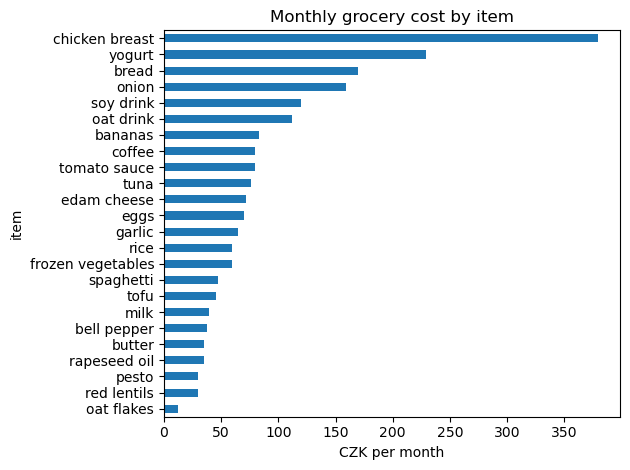

Total monthly grocery basket: 2126 CZK

Top 3 most expensive items:
          item  monthly_cost  share_pct
chicken breast         379.6  17.853783
        yogurt         229.0  10.770591
         bread         170.0   7.995635


In [28]:
basket = load_groceries_basket()

basket_sorted = basket.sort_values("monthly_cost", ascending=True)
basket_sorted.plot.barh(x="item", y="monthly_cost", legend=False)
plt.title("Monthly grocery cost by item")
plt.xlabel("CZK per month")
plt.tight_layout()
plt.show()

# Share of total budget
basket["share_pct"] = basket["monthly_cost"] / basket["monthly_cost"].sum() * 100
top3 = basket.nlargest(3, "share_pct")[["item", "monthly_cost", "share_pct"]]
print(f"Total monthly grocery basket: {basket['monthly_cost'].sum():.0f} CZK")
print(f"\nTop 3 most expensive items:")
print(top3.to_string(index=False))

2. Store comparison 

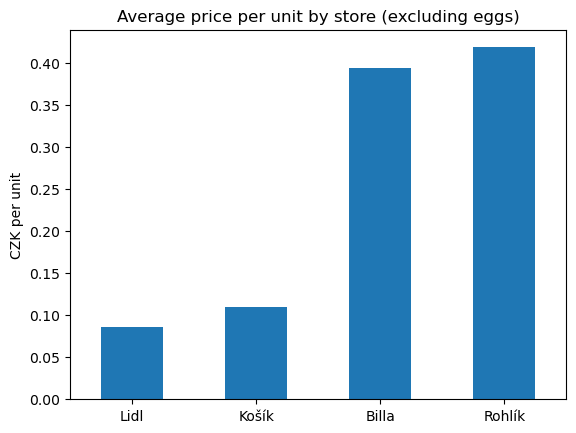

Cheapest store on average: Lidl (0.086 CZK/unit)
Most expensive: Rohlík (0.418 CZK/unit)
Difference: 384.3%


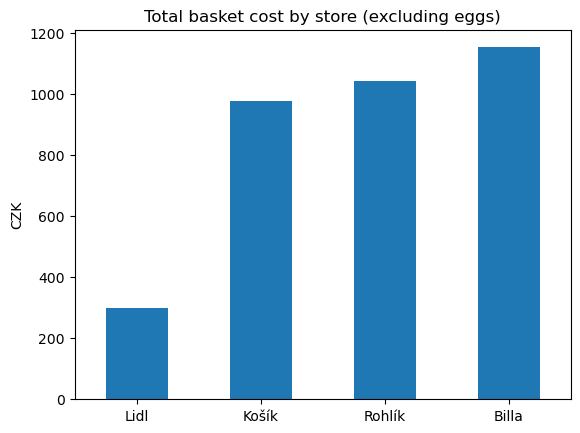


Note: Lidl has most missing prices — basket total is underestimated for Lidl
billa_price_czk      0
lidl_price_czk      13
kosik_price_czk      0
rohlik_price_czk     0
dtype: int64


In [29]:
groceries_full = load_groceries_full()

# Exclude eggs - incompatible units across stores
no_eggs = groceries_full[groceries_full["item"] != "vejce"].copy()

store_prices = no_eggs[["item", "billa_price_per_unit", "lidl_price_per_unit",
                          "kosik_price_per_unit", "rohlik_price_per_unit"]].copy()
store_prices.columns = ["item", "Billa", "Lidl", "Košík", "Rohlík"]
store_prices = store_prices.set_index("item")

# Average price per unit (excludes NaN automatically)
store_means = store_prices.mean().sort_values()
store_means.plot.bar()
plt.title("Average price per unit by store (excluding eggs)")
plt.ylabel("CZK per unit")
plt.xticks(rotation=0)
plt.show()

cheapest_store = store_means.idxmin()
print(f"Cheapest store on average: {cheapest_store} ({store_means.min():.3f} CZK/unit)")
print(f"Most expensive: {store_means.idxmax()} ({store_means.max():.3f} CZK/unit)")
print(f"Difference: {((store_means.max() - store_means.min()) / store_means.min() * 100):.1f}%")

# Total basket cost per store
basket_totals = no_eggs[["billa_price_czk", "lidl_price_czk",
                           "kosik_price_czk", "rohlik_price_czk"]].sum()
basket_totals.index = ["Billa", "Lidl", "Košík", "Rohlík"]
basket_totals.sort_values().plot.bar()
plt.title("Total basket cost by store (excluding eggs)")
plt.ylabel("CZK")
plt.xticks(rotation=0)
plt.show()

print("\nNote: Lidl has most missing prices — basket total is underestimated for Lidl")
print(groceries_full[["billa_price_czk","lidl_price_czk",
                        "kosik_price_czk","rohlik_price_czk"]].isna().sum())


3. Canteen vs groceries

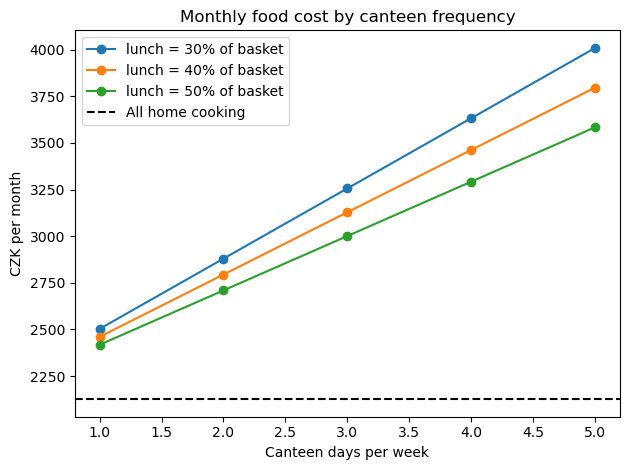

All home cooking baseline: 2126 CZK/month

lunch=30%: full canteen costs +1883 CZK/month vs all home
lunch=40%: full canteen costs +1670 CZK/month vs all home
lunch=50%: full canteen costs +1458 CZK/month vs all home


In [30]:
basket_monthly = load_groceries_basket()["monthly_cost"].sum()
canteen = load_canteen()

lunch_shares = [0.3, 0.4, 0.5]
fig, ax = plt.subplots()

for lunch_share in lunch_shares:
    home_lunch_cost = basket_monthly * lunch_share
    other_food_cost = basket_monthly * (1 - lunch_share)
    results = []
    for _, row in canteen.iterrows():
        days = row["days_per_week"]
        home_lunch_remaining = home_lunch_cost * (5 - days) / 5
        total_food = other_food_cost + home_lunch_remaining + row["monthly_cost"]
        results.append({"days_per_week": days, "total_food": total_food})
    pd.DataFrame(results).set_index("days_per_week")["total_food"].plot(
        ax=ax, marker="o", label=f"lunch = {lunch_share:.0%} of basket"
    )

ax.axhline(basket_monthly, linestyle="--", color="black", label="All home cooking")
ax.set_title("Monthly food cost by canteen frequency")
ax.set_ylabel("CZK per month")
ax.set_xlabel("Canteen days per week")
ax.legend()
plt.tight_layout()
plt.show()

# Conclusions
print(f"All home cooking baseline: {basket_monthly:.0f} CZK/month\n")
for lunch_share in lunch_shares:
    home_lunch_cost = basket_monthly * lunch_share
    other_food_cost = basket_monthly * (1 - lunch_share)
    rows = []
    for _, row in canteen.iterrows():
        days = row["days_per_week"]
        home_lunch_remaining = home_lunch_cost * (5 - days) / 5
        total_food = other_food_cost + home_lunch_remaining + row["monthly_cost"]
        rows.append({"days_per_week": days, "total_food": total_food})
    df_s = pd.DataFrame(rows)
    extra_5 = df_s.loc[df_s["days_per_week"]==5, "total_food"].iloc[0] - basket_monthly
    print(f"lunch={lunch_share:.0%}: full canteen costs {extra_5:+.0f} CZK/month vs all home")

The standard grocery basket costs around 2 126 CZK/month.   
Physical stores are cheaper than online stores, though Lidl data is incomplete so exact savings are hard to quantify. Canteen use consistently increases food costs compared to home cooking by 1 200–1 670 CZK/month depending on how large a share of the grocery budget goes to lunch.   
For a budget-conscious student, cooking at home and shopping at physical stores is the most cost-effective food strategy.

### Overview model

In [31]:
import inspect
from source_code.cost_model import compute_monthly_cost
print(inspect.getsource(compute_monthly_cost))

def compute_monthly_cost(
        housing_cost: float,
        canteen_days: int = 5,
        groceries: float = None,
        transport: float = TRANSPORT_MONTHLY,
        leisure: float = LEISURE_MONTHLY,
        lunch_share: float = 0.4) -> dict:

    full_grocery_basket = load_groceries_basket()["monthly_cost"].sum()
    
    if groceries is None:
        # Scale down groceries based on how many lunches canteen covers
        home_lunch_cost = full_grocery_basket * lunch_share
        other_food_cost = full_grocery_basket * (1 - lunch_share)
        home_lunch_remaining = home_lunch_cost * (5 - canteen_days) / 5
        groceries = other_food_cost + home_lunch_remaining

    canteen_cost = get_canteen_cost(canteen_days)

    breakdown = {
        "housing": housing_cost,
        "canteen": canteen_cost,
        "groceries": groceries,
        "transport": transport,
        "leisure": leisure
    }
    breakdown["total"] = sum(breakdown.values())
    return breakdown



In [45]:
df5=build_scenario_table(canteen_days=5)
df_sorted = df5.sort_values("total")
df_sorted

,housing,canteen,groceries,transport,leisure,total,type
label,,,,,,,
Dorm 4-bed (shared facilities),3765.000000,2520.8,1275.696,106.666667,2000,9668.162667,dorm
Dorm 3-bed (own facilities),3975.000000,2520.8,1275.696,106.666667,2000,9878.162667,dorm
Dorm 3-bed (shared facilities),4087.500000,2520.8,1275.696,106.666667,2000,9990.662667,dorm
Dorm 2-bed (shared facilities),4815.000000,2520.8,1275.696,106.666667,2000,10718.162667,dorm
Dorm 2-bed (own facilities),5910.000000,2520.8,1275.696,106.666667,2000,11813.162667,dorm
Dorm 1-bed (shared facilities),6120.000000,2520.8,1275.696,106.666667,2000,12023.162667,dorm
Dorm 1-bed (own facilities),8035.000000,2520.8,1275.696,106.666667,2000,13938.162667,dorm
Flat 3+KK outer_or_suburbs,10536.373333,2520.8,1275.696,106.666667,2000,16439.536000,apartment
Flat 3+KK inner_city,11940.160256,2520.8,1275.696,106.666667,2000,17843.322923,apartment


In [43]:
df0=build_scenario_table(canteen_days=0)
df0

,housing,canteen,groceries,transport,leisure,total,type
label,,,,,,,
Dorm 1-bed (shared facilities),6120.000000,0,2126.16,106.666667,2000,10352.826667,dorm
Dorm 1-bed (own facilities),8035.000000,0,2126.16,106.666667,2000,12267.826667,dorm
Dorm 2-bed (shared facilities),4815.000000,0,2126.16,106.666667,2000,9047.826667,dorm
Dorm 2-bed (own facilities),5910.000000,0,2126.16,106.666667,2000,10142.826667,dorm
Dorm 3-bed (shared facilities),4087.500000,0,2126.16,106.666667,2000,8320.326667,dorm
Dorm 3-bed (own facilities),3975.000000,0,2126.16,106.666667,2000,8207.826667,dorm
Dorm 4-bed (shared facilities),3765.000000,0,2126.16,106.666667,2000,7997.826667,dorm
Flat 1+KK center,25472.857143,0,2126.16,106.666667,2000,29705.683810,apartment
Flat 2+KK center,16175.625000,0,2126.16,106.666667,2000,20408.451667,apartment


In [46]:
print(f"Saving from home cooking vs full canteen: {(df5['total'] - df0['total']).iloc[0]:.0f} CZK/month")

Saving from home cooking vs full canteen: 1670 CZK/month


<Axes: ylabel='label'>

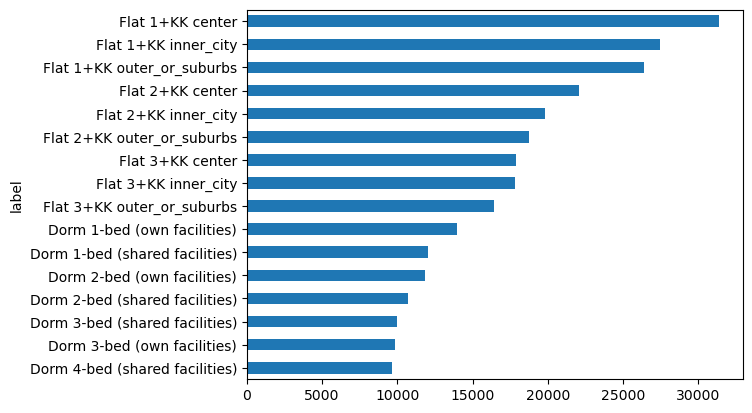

In [38]:
df_sorted["total"].plot.barh()

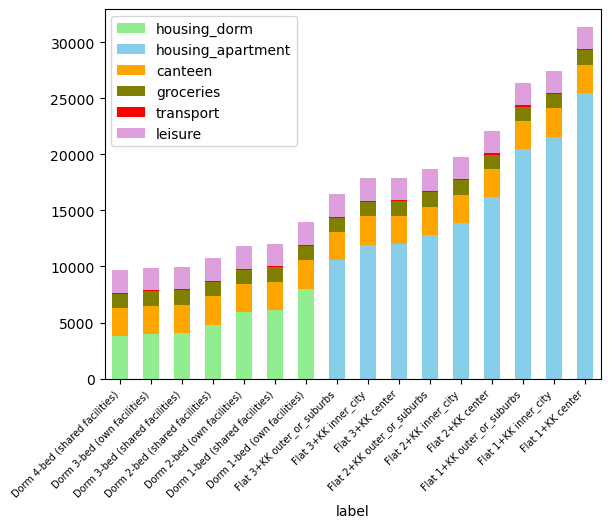

In [ ]:
parts=["housing_dorm","housing_apartment","canteen","groceries","transport","leisure"]

df_sorted["housing_dorm"] =df_sorted["housing"].where(df_sorted["type"]=="dorm", 0)
df_sorted["housing_apartment"] =df_sorted["housing"].where(df_sorted["type"]=="apartment", 0)

colors={
    "housing_dorm":"lightgreen",
    "housing_apartment":"skyblue",
    "canteen":"orange",
    "groceries":"olive",
    "transport":"red",
    "leisure":"plum"}

df_sorted[parts].plot.bar(stacked=True,color=[colors[p]for p in parts])
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.savefig("figures/total_costs.png",bbox_inches="tight")
plt.show()

In [48]:
insights = get_cost_insights()
print(f"Cheapest option: {insights['cheapest_option']['name']} — {insights['cheapest_option']['cost']:.0f} CZK/month")
print(f"Most expensive: {insights['most_expensive_option']['name']} — {insights['most_expensive_option']['cost']:.0f} CZK/month")
print(f"Dorm average: {insights['dorm_average']:.0f} CZK/month")
print(f"Apartment average: {insights['apartment_average']:.0f} CZK/month")
print(f"Housing accounts for {insights['housing_dominance']:.1f}% of average total cost")

Cheapest option: Dorm 4-bed (shared facilities) — 9668 CZK/month
Most expensive: Flat 1+KK center — 31376 CZK/month
Dorm average: 11147 CZK/month
Apartment average: 21997 CZK/month
Housing accounts for 65.8% of average total cost


Monthly cost of living for a Prague student ranges from 7 998 CZK to 31 376 CZK 
depending on housing and eating habits — a nearly 4x difference.

As shown in the chart, housing dominates the total budget across all scenarios.   
Food choices (canteen vs home cooking) add up to 1 670 CZK/month difference — 
significant but secondary to housing decisions.

For students with dorm access, even the most expensive dorm (1-bed own facilities, 
full canteen) at 13 938 CZK/month is cheaper than the cheapest apartment option 
(3+KK outer suburbs, home cooking) at 14 769 CZK/month.

For students without dorm access, sharing a larger apartment in outer Prague 
is the most cost-effective strategy, with per-person costs approaching dorm levels.